# 01 - Exploratory Data Analysis

**Dataset:** IMDB 50k movie reviews (binary sentiment).

**Goal:** Understad size, balance, length, and data quality     before modeling and record implications for the train/val/test split and DistilBERT fine-tuning

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', 200)
sns.set_theme(style="whitegrid")


In [2]:
# Load the dataset

df = pd.read_csv('../data/IMDB Dataset.csv')
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire p...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue i...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenl...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what mone...",positive


## Data quality: nulls and duplicates

Checked before splitting: duplicate reviews landing in different splits would leak information and inflate the scores.

In [3]:
print("Missing values:\n", df.isnull().sum(),"\n")
print("Duplicate reviews:\n", df.duplicated().sum(),"\n")

Missing values:
 review       0
sentiment    0
dtype: int64 

Duplicate reviews:
 418 



## Class balance

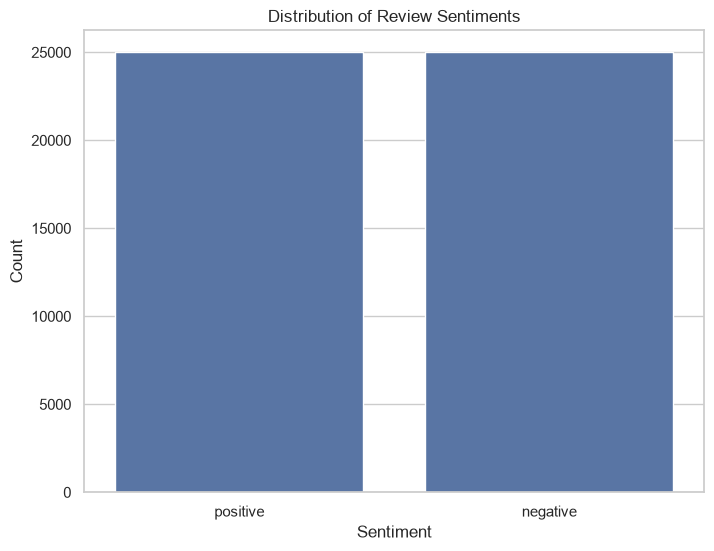

sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


In [4]:
figure, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, ax=ax)
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

print(df['sentiment'].value_counts(normalize=True))

Perfectly balanced — 25k positive / 25k negative. Accuracy is a fair metric,
and no class weighting or resampling is needed.

## Review length (in words)

Length in words, because it maps to DistilBERT's 512-token limit: inputs longer
than that get truncated, so we want to know how many reviews are affected.

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


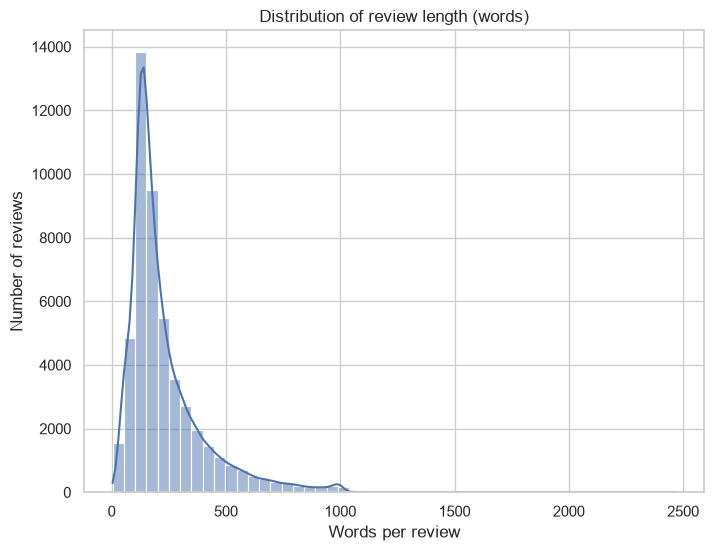

13.0% of revies exceed 400 words which would likely truncated at 512 tokens


In [5]:
df['word_count'] = df['review'].str.split().str.len()
print(df['word_count'].describe())

figure, ax = plt.subplots(figsize=(8, 6))
sns.histplot(df['word_count'], bins=50, kde=True, ax=ax)
ax.set_title('Distribution of review length (words)')
ax.set_xlabel('Words per review'); ax.set_ylabel('Number of reviews')
plt.show()

# ~512 tokens would be around 400 words 
# percentage of reviews over that length
over = (df['word_count'] > 400).mean()
print(f"{over:.1%} of revies exceed 400 words which would likely truncated at 512 tokens")

## A look at raw examples

Reading raw text surfaces quirks the stats hide - note the leftover '<br />' HTML tags, a candidate for cleaning before the TF-IDF baseline

In [6]:
for label in ['positive', 'negative']:
    print(f"---{label.upper()}---")
    print(df[df['sentiment'] == label]['review'].iloc[0][:300],"...\n")

---POSITIVE---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...

---NEGATIVE---
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma ...



## Takeaways for modeling

- 50,000 reviews, **50/50 balanced** → accuracy and F1 both fair; no resampling.
- Duplicates found: **418** → de-duplicate before splitting.
- ~**13%** of reviews exceed ~400 words → truncated by DistilBERT; acceptable for sentiment.
- `<br />` tags present → clean before the TF-IDF baseline.

**Next:** `02` — deterministic train/validation/test split (fixed seed, de-duplicated),
saved to disk for reproducibility.